# NeuraEval — Day 6: Train First Classifier
**Goal:** an honest baseline 4-class stage classifier (0 Healthy / 1 Mild / 2 Moderate / 3 Severe).

**Discipline:** fit on **train**, evaluate on **val**, leave **test sealed** until the end of the project.
Two models: **A** (primary, no CDR) and **B** (cheating, with CDR). Their gap measures the CDR leakage.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)

DATA_DIR = '../data'   # notebook runs from notebooks/ -> repo-root data/
print('Imports complete.')

Imports complete.


## 2. Load data (train + val only — test stays sealed)

In [2]:
# Load ONLY train and val. The test set stays sealed until the very end of the project.
train = pd.read_csv(f'{DATA_DIR}/train.csv')
val   = pd.read_csv(f'{DATA_DIR}/val.csv')

# Encode sex as a number (M -> 0, F -> 1) so the model can use it.
for df in (train, val):
    df['sex'] = df['sex'].map({'M': 0, 'F': 1})

print(f'train: {train.shape}   val: {val.shape}')
print('Stages in train:', dict(train['stage'].value_counts().sort_index()))

train: (350, 17)   val: (75, 17)
Stages in train: {0: np.int64(108), 1: np.int64(121), 2: np.int64(82), 3: np.int64(39)}


## 3. Feature sets

In [3]:
# Drop the identifier and the label; everything else is a candidate feature.
drop_cols = ['patient_id', 'stage']
feats_all = [c for c in train.columns if c not in drop_cols]

# Model A = primary: every feature EXCEPT cdr (cdr is label-in-disguise, Day 4).
# Model B = cheating baseline: same features PLUS cdr, to measure the leakage.
feats_A = [c for c in feats_all if c != 'cdr']
feats_B = feats_all

y_train, y_val = train['stage'], val['stage']

print('Model A (no cdr) :', feats_A)
print('Model B (with cdr):', feats_B)

Model A (no cdr) : ['age', 'sex', 'bmi', 'years_education', 'family_history', 'depression', 'sleep_disorder', 'constipation', 'mmse', 'tremor', 'rigidity', 'bradykinesia', 'postural_instability', 'speech_problems']
Model B (with cdr): ['age', 'sex', 'bmi', 'years_education', 'family_history', 'depression', 'sleep_disorder', 'constipation', 'mmse', 'cdr', 'tremor', 'rigidity', 'bradykinesia', 'postural_instability', 'speech_problems']


## 4. Model A — primary (no CDR)

Standardize the features (fit on **train only** — no leakage), then logistic regression with
`class_weight='balanced'` so severe (~11%) is not ignored.

In [4]:
def train_and_eval(feats, name):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)
    )
    model.fit(train[feats], y_train)      # fit on train
    pred = model.predict(val[feats])      # evaluate on val (test stays sealed)

    acc  = accuracy_score(y_val, pred)
    bacc = balanced_accuracy_score(y_val, pred)
    mf1  = f1_score(y_val, pred, average='macro')
    print(f'=== {name} ({len(feats)} features) ===')
    print(f'accuracy {acc:.3f} | balanced_acc {bacc:.3f} | macro-F1 {mf1:.3f}\n')
    print(classification_report(
        y_val, pred,
        target_names=['0-Healthy', '1-Mild', '2-Moderate', '3-Severe'],
        digits=2, zero_division=0))
    return model, pred, {'acc': acc, 'bacc': bacc, 'mf1': mf1}

model_A, pred_A, res_A = train_and_eval(feats_A, 'Model A - primary (no CDR)')

=== Model A - primary (no CDR) (14 features) ===
accuracy 0.880 | balanced_acc 0.907 | macro-F1 0.907

              precision    recall  f1-score   support

   0-Healthy       0.78      0.91      0.84        23
      1-Mild       0.87      0.77      0.82        26
  2-Moderate       1.00      0.94      0.97        18
    3-Severe       1.00      1.00      1.00         8

    accuracy                           0.88        75
   macro avg       0.91      0.91      0.91        75
weighted avg       0.89      0.88      0.88        75



## 5. Model B — cheating baseline (with CDR)

In [5]:
model_B, pred_B, res_B = train_and_eval(feats_B, 'Model B - cheating (with CDR)')

=== Model B - cheating (with CDR) (15 features) ===
accuracy 0.933 | balanced_acc 0.951 | macro-F1 0.949

              precision    recall  f1-score   support

   0-Healthy       0.85      0.96      0.90        23
      1-Mild       0.96      0.85      0.90        26
  2-Moderate       1.00      1.00      1.00        18
    3-Severe       1.00      1.00      1.00         8

    accuracy                           0.93        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.94      0.93      0.93        75



## 6. The leakage gap (B − A)

In [6]:
# The gap between the cheating model and the honest one = the leakage cdr buys.
# This is a NeuraEval deliverable, not a footnote.
print('Leakage gap (Model B - Model A):')
print(f"  accuracy : +{res_B['acc'] - res_A['acc']:.3f}")
print(f"  macro-F1 : +{res_B['mf1'] - res_A['mf1']:.3f}")

Leakage gap (Model B - Model A):
  accuracy : +0.053
  macro-F1 : +0.042


## 7. Confusion matrix — where does the honest model fail?

Confusion matrix, Model A (rows = true, cols = predicted):
[[21  2  0  0]
 [ 6 20  0  0]
 [ 0  1 17  0]
 [ 0  0  0  8]]


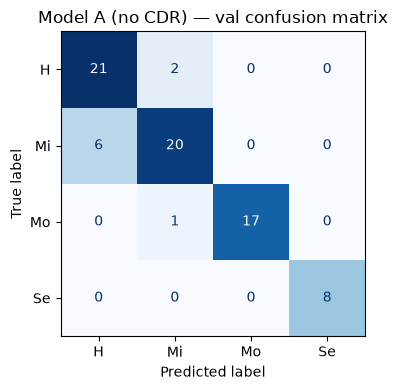

Saved -> notes/figures/day6_confusion_matrix.png


In [7]:
# Day 4 predicted errors would concentrate in the adjacent-stage overlap band. Check it.
cm = confusion_matrix(y_val, pred_A)
print('Confusion matrix, Model A (rows = true, cols = predicted):')
print(cm)

os.makedirs('../notes/figures', exist_ok=True)
disp = ConfusionMatrixDisplay(cm, display_labels=['H', 'Mi', 'Mo', 'Se'])
fig, ax = plt.subplots(figsize=(4.5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Model A (no CDR) — val confusion matrix')
plt.tight_layout()
plt.savefig('../notes/figures/day6_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> notes/figures/day6_confusion_matrix.png')

## 8. What the model learned (coefficients)

In [8]:
# Which features drive Model A? Mean absolute coefficient across the 4 one-vs-rest rows.
coef = np.abs(model_A.named_steps['logisticregression'].coef_).mean(axis=0)
importance = sorted(zip(feats_A, coef), key=lambda x: -x[1])
print('Model A feature importance (mean |coef|):')
for f, c in importance:
    print(f'  {f:22s} {c:.3f}')

Model A feature importance (mean |coef|):
  mmse                   1.648
  tremor                 1.235
  speech_problems        1.205
  bradykinesia           1.198
  postural_instability   0.999
  rigidity               0.919
  sleep_disorder         0.422
  constipation           0.326
  depression             0.259
  age                    0.256
  family_history         0.207
  sex                    0.177
  bmi                    0.129
  years_education        0.073


## 9. Day 6 reflection

Write `notes/day6_reflection.md` in your own words:
1. Where did Model A's errors land in the confusion matrix — do they match the overlap band you predicted on Day 4?
2. How big was the CDR leakage gap, and does keeping CDR as a *baseline* (not a feature) still feel right?
3. Which features carried the model — does that match the Day 4 story (motor + MMSE strong; bmi/education/family_history near-null)?

**Test is still sealed.** Do not load `test.csv` — that is for the very end of the project.